<br>

<div align="center">
<span style="font-size: 2.5em;">Monte Carlo Recoil Spectra Visualization</span>
<br>
<span style="font-size: 1.2em; color: gray;">Exploring binning strategies for different DM masses and couplings</span>
</div>

## Overview

This notebook visualizes WIMP recoil energy spectra for different parameter combinations, comparing linear and logarithmic binning strategies.

### Key Considerations

**Binning Strategy**: 
- Recoil spectra are exponentially distributed
- Logarithmic bins provide better resolution in high-event regions
- Linear bins useful for visualization but may miss structure at low energies

**Physical Constraints**:
- MC threshold: 1.0 keV (realistic threshold would be slightly higher)
- Event rate scales as $\propto c_p^2$
- Target regime: ~100 events → requires moderate coupling values

## Setup

Load the project modules and define the parameter grid used by the spectrum visualizations.

In [1]:
import os

desired_root_name = "xenon-sbi"
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import matplotlib.pyplot as plt
import numpy as np

from configs.config import MCConfig
from data.mc_generator import mc_generator

In [2]:
masses = [5, 50, 500]
couplings = [1e-8, 1e-9, 1e-10]

## Shared Plotting Utilities

The functions below generate spectra once and provide consistent layouts for the standard and annotated comparisons.

In [3]:
def generate_spectra_grid(masses, couplings, mc_config):
    """Generate MC events and histogram metadata for every parameter pair."""
    spectra = {}
    for mass in masses:
        for coupling in couplings:
            events, counts, bin_edges, nevents = mc_generator(
                mchi=mass,
                cp=coupling,
                **mc_config.__dict__,
            )
            spectra[(mass, coupling)] = {
                "events": events,
                "counts": counts,
                "bin_edges": bin_edges,
                "nevents": nevents,
            }
    return spectra


def plot_spectra_grid(
    masses,
    couplings,
    mc_config,
    *,
    log_counts=False,
    title=None,
    color="steelblue",
):
    """Plot a mass-by-coupling grid and return the figure, axes, and spectra."""
    spectra = generate_spectra_grid(masses, couplings, mc_config)
    fig, axes = plt.subplots(
        len(masses),
        len(couplings),
        figsize=(4 * len(couplings), 3.5 * len(masses)),
        squeeze=False,
        sharex=True,
    )

    for row, mass in enumerate(masses):
        for column, coupling in enumerate(couplings):
            ax = axes[row, column]
            spectrum = spectra[(mass, coupling)]
            ax.hist(
                spectrum["events"],
                bins=spectrum["bin_edges"],
                color=color,
                alpha=0.75,
                linewidth=0.5,
                log=log_counts,
            )
            ax.set_title(f"$m_\\chi$ = {mass} GeV, $c_p$ = {coupling:.0e}", fontsize=10)
            ax.grid(alpha=0.3, which="both" if log_counts else "major")

            if row == len(masses) - 1:
                ax.set_xlabel("Recoil Energy [keV]", fontsize=9)
            if column == 0:
                ylabel = "Counts (log scale)" if log_counts else "Counts"
                ax.set_ylabel(ylabel, fontsize=9)

    if title:
        fig.suptitle(title, fontsize=14, y=1.02)
    fig.tight_layout()
    return fig, axes, spectra


def plot_annotated_spectra_grid(
    masses,
    couplings,
    mc_config,
    *,
    log_transform=True,
    title=None,
    color="#67000d",
):
    """Plot an annotated mass-by-coupling grid with consistent y-limits."""
    spectra = generate_spectra_grid(masses, couplings, mc_config)
    n_rows, n_columns = len(couplings), len(masses)
    values = {}

    for row, coupling in enumerate(couplings):
        for column, mass in enumerate(masses):
            counts = spectra[(mass, coupling)]["counts"]
            values[(row, column)] = np.log10(counts + 1) if log_transform else counts

    global_max = max((np.max(value) for value in values.values() if value.size), default=0)
    y_limit = max(1.0 if log_transform else 5.0, 1.2 * global_max)
    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(5.5 * n_columns, 5.0 * n_rows),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    for row, coupling in enumerate(couplings):
        for column, mass in enumerate(masses):
            ax = axes[row, column]
            spectrum = spectra[(mass, coupling)]
            bin_edges = spectrum["bin_edges"]
            ax.bar(
                bin_edges[:-1],
                values[(row, column)],
                width=np.diff(bin_edges),
                align="edge",
                color=color,
                alpha=0.9,
                linewidth=0,
            )
            ax.set_ylim(0, y_limit)
            ax.grid(alpha=0.35)
            ax.tick_params(axis="both", labelsize=16)
            annotation = (
                rf"$m_\chi = {mass}\,\mathrm{{GeV}}$"
                + "\n"
                + rf"$c_p = {coupling:.1e}$"
                + "\n"
                + rf"$N = {spectrum['nevents']}$"
            )
            ax.text(
                0.94,
                0.92,
                annotation,
                transform=ax.transAxes,
                va="top",
                ha="right",
                fontsize=15,
                bbox=dict(
                    boxstyle="round,pad=0.5",
                    facecolor="white",
                    edgecolor="black",
                    linewidth=1.0,
                    alpha=0.95,
                ),
            )

            if row == n_rows - 1:
                ax.set_xlabel("Recoil Energy [keV]", fontsize=18)
            if column == 0:
                ax.set_ylabel(
                    "log10(1 + Counts)" if log_transform else "Counts",
                    fontsize=18,
                )

    if title:
        fig.suptitle(title, fontsize=24, y=0.995)
    fig.tight_layout()
    return fig, axes, spectra

## 0. Differential Recoil Rates vs. Dark Matter Mass

How does the recoil rate spectrum change with WIMP mass? This section compares differential recoil rates $\frac{dR}{dE}$ across different mass regimes for a fixed coupling strength.

**Key Physics**:
- Light WIMPs: Produce abundant but soft recoils (low energies)
- Heavy WIMPs: Produce fewer but harder recoils (high energies)
- Rate scales as $\propto c_p^2$ independently of mass
- Different kinematics lead to very different energy distributions

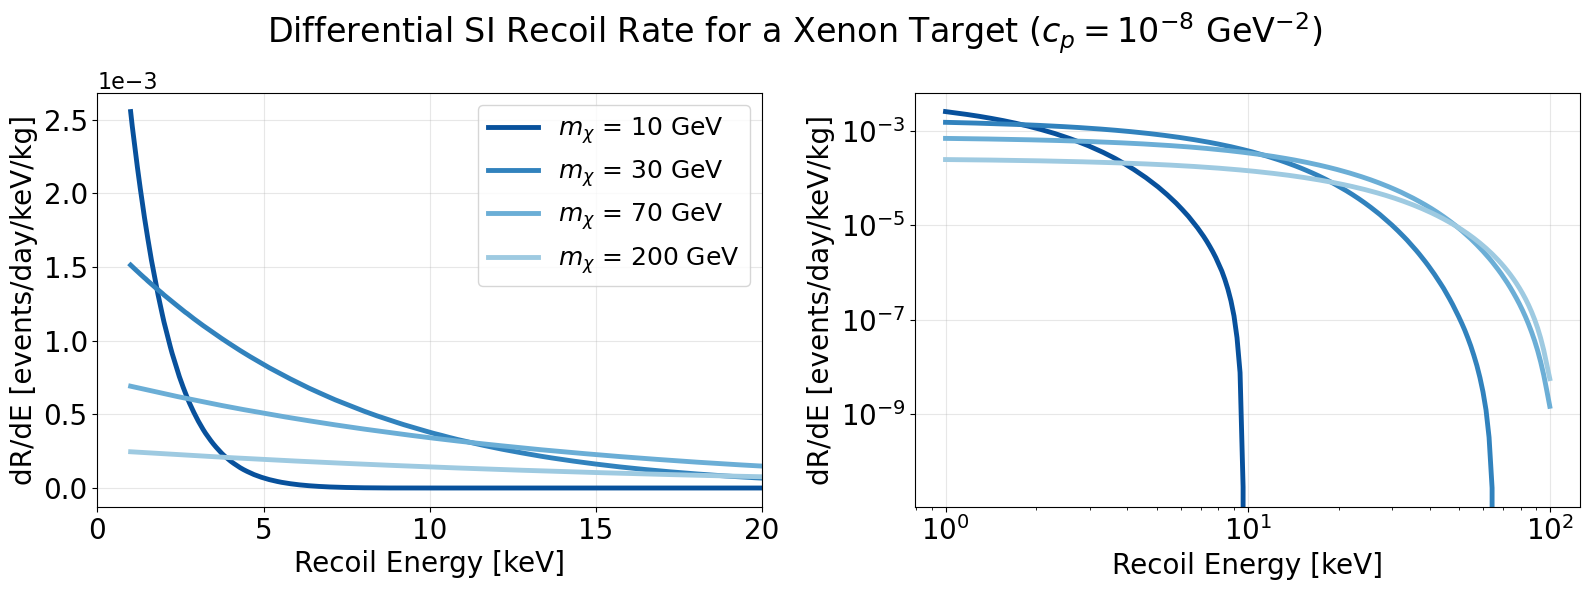

In [4]:
from data.mc_generator import calculate_diff_rate

er_min, er_max = 1.0, 100.0
n_points = 200
er_vec = np.logspace(np.log10(er_min), np.log10(er_max), n_points)

fixed_coupling = 1e-8
masses_to_compare = [10, 30, 70, 200]
rates_by_mass = {
    mass: calculate_diff_rate(
        mchi=mass,
        c_p=fixed_coupling,
        er_vec=er_vec,
    )
    for mass in masses_to_compare
}

blues = ["#08519c", "#3182bd", "#6baed6", "#9ecae1"]
fig, (ax_linear, ax_log) = plt.subplots(1, 2, figsize=(16, 6))

for mass, color in zip(masses_to_compare, blues):
    label = f"$m_\\chi$ = {mass} GeV"
    ax_linear.plot(er_vec, rates_by_mass[mass], label=label, linewidth=3.5, color=color)
    ax_log.loglog(er_vec, rates_by_mass[mass], label=label, linewidth=3.5, color=color)

ax_linear.set_xlabel("Recoil Energy [keV]", fontsize=20)
ax_linear.set_ylabel("dR/dE [events/day/keV/kg]", fontsize=20)
ax_linear.legend(fontsize=18, loc="upper right")
ax_linear.grid(alpha=0.3, linewidth=0.8)
ax_linear.tick_params(labelsize=20)
ax_linear.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax_linear.set_xlim(0, 20)
ax_linear.yaxis.get_offset_text().set_fontsize(16)

ax_log.set_xlabel("Recoil Energy [keV]", fontsize=20)
ax_log.set_ylabel("dR/dE [events/day/keV/kg]", fontsize=20)
ax_log.grid(alpha=0.3, linewidth=0.8, which="major")
ax_log.tick_params(labelsize=20)

exp = int(f"{fixed_coupling:.0e}".split("e")[1])
fig.suptitle(
    rf"Differential SI Recoil Rate for a Xenon Target ($c_p = 10^{{{exp}}}~\mathrm{{GeV}}^{{-2}}$)",
    fontsize=24,
    y=0.975,
)
fig.tight_layout()
plt.show()

## 1. Linear Binning

Standard histogram with linearly spaced energy bins.

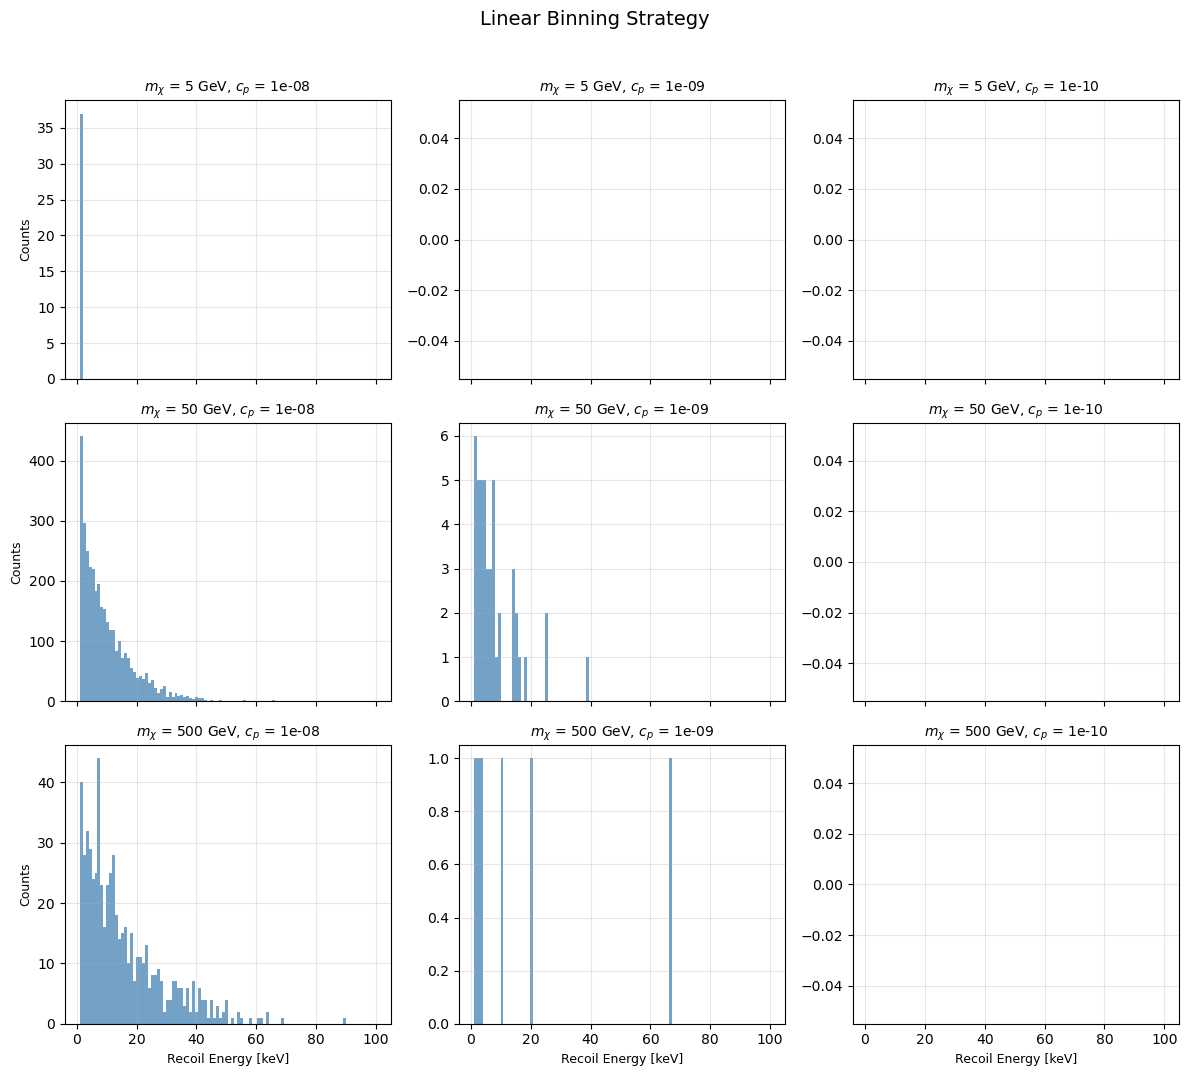

In [5]:
mc_cfg = MCConfig(log_bins=False)
fig, axes, spectra = plot_spectra_grid(
    masses,
    couplings,
    mc_cfg,
    title="Linear Binning Strategy",
)
plt.show()

In [6]:
# Inspect the spectrum generated by the linear-binning plot
spectrum = spectra[(50, 1e-8)]

print(f"Total events: {spectrum['nevents']}")
print(f"Bin counts: {spectrum['counts'][:10]}...")

Total events: 3442
Bin counts: [441 296 250 223 220 184 195 157 154 131]...


## 2. Logarithmic Binning (Linear Counts)

Logarithmically spaced energy bins to better capture the exponential spectrum shape.

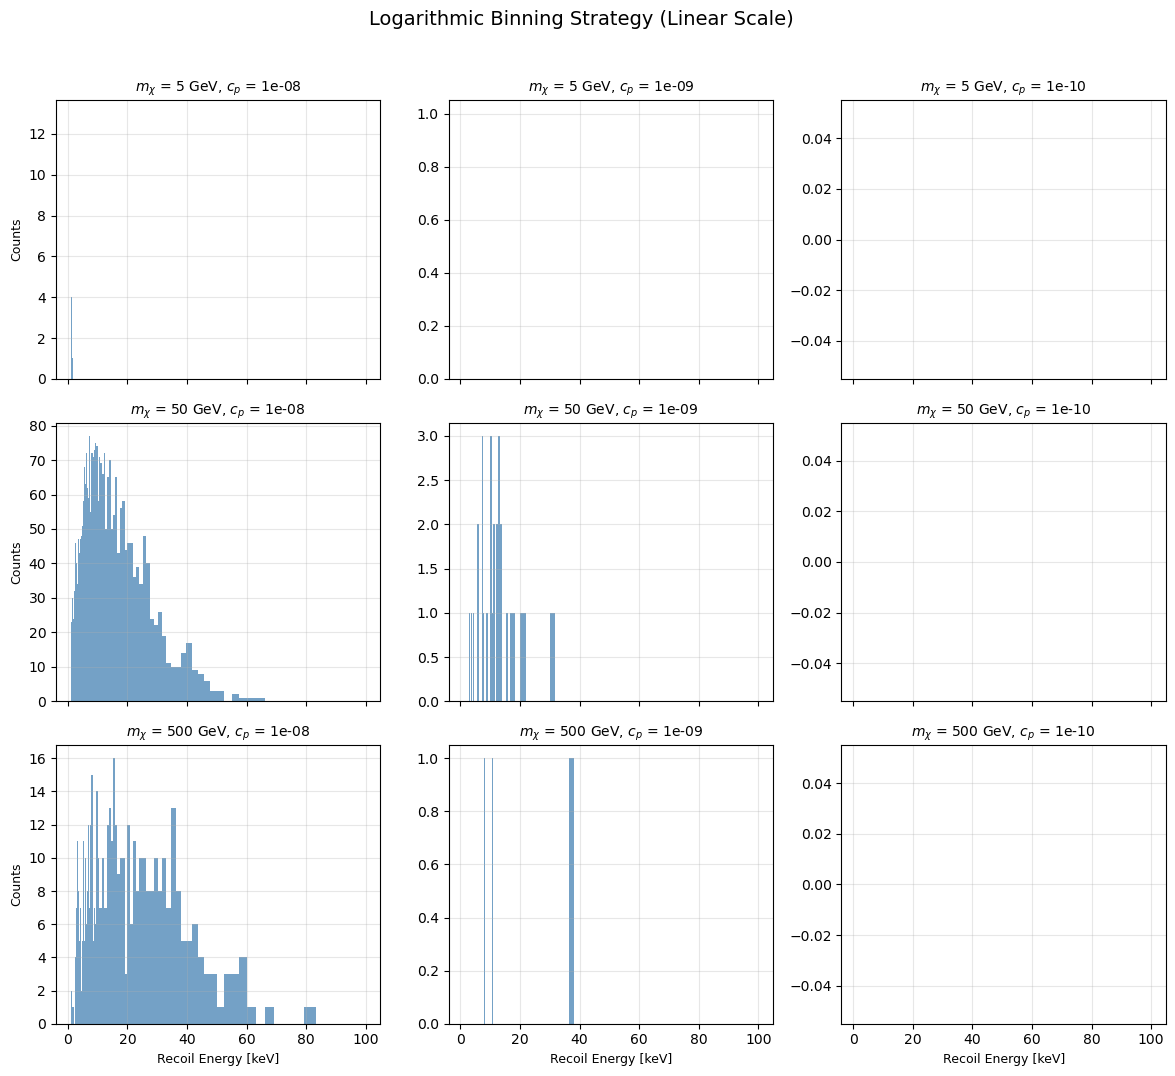

In [7]:
mc_cfg = MCConfig(log_bins=True)
fig, axes, spectra = plot_spectra_grid(
    masses,
    couplings,
    mc_cfg,
    title="Logarithmic Binning Strategy (Linear Scale)",
)
plt.show()

In [8]:
# Inspect the spectrum generated by the log-binning plot
spectrum = spectra[(50, 1e-8)]

print(f"Total events: {spectrum['nevents']}")
print(f"Bin counts: {spectrum['counts'][:10]}...")
print(f"Bin edges (first 5): {spectrum['bin_edges'][:5]}")

Total events: 3503
Bin counts: [32 13 14 16 23 18 23 28 29 30]...
Bin edges (first 5): [1.         1.04712855 1.0964782  1.14815362 1.20226443]


## 3. Logarithmic Binning (Log Counts)

Logarithmically spaced bins with log-scale counts for better visualization across different event rate scales.

C:\Users\nikla\AppData\Local\Temp\ipykernel_25120\178779459.py:43: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.hist(
C:\Users\nikla\AppData\Local\Temp\ipykernel_25120\178779459.py:62: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.tight_layout()


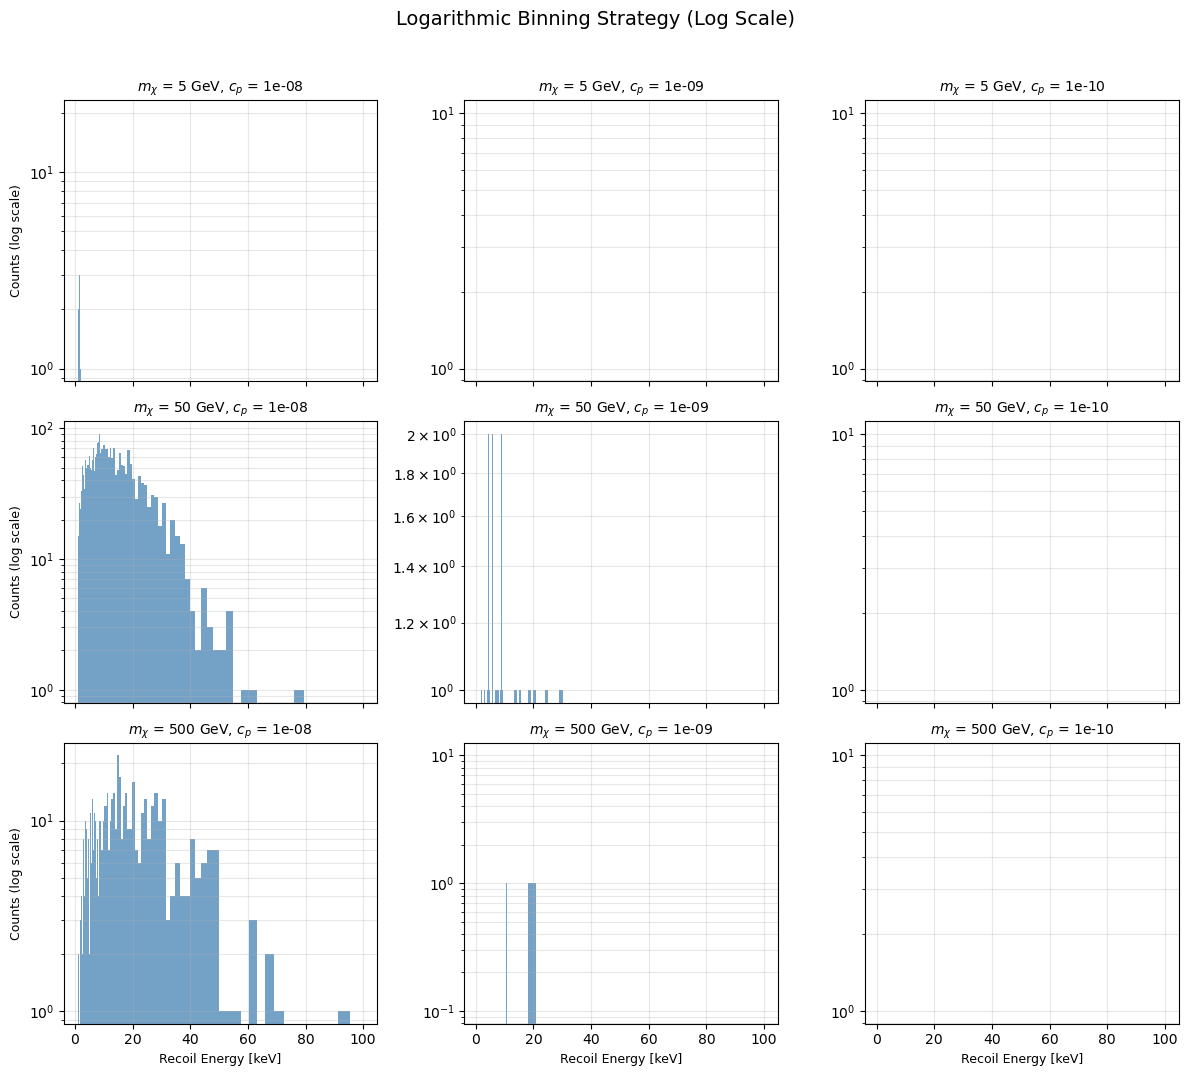

In [9]:
fig, axes, spectra = plot_spectra_grid(
    masses,
    couplings,
    mc_cfg,
    log_counts=True,
    title="Logarithmic Binning Strategy (Log Scale)",
)
plt.show()

In [10]:
# Inspect log-transformed counts from the log-binning plot
spectrum = spectra[(50, 1e-8)]
counts = spectrum["counts"]

print(f"Total events: {spectrum['nevents']}")
print(f"Log(counts + 1) for first 10 bins: {np.log10(counts[:10] + 1)}")
print(f"Log(total events + 1): {np.log10(spectrum['nevents'] + 1):.2f}")

Total events: 3510
Log(counts + 1) for first 10 bins: [1.41497335 0.95424251 1.30103    1.38021124 1.20411998 1.39794001
 1.44715803 1.38021124 1.34242268 1.44715803]
Log(total events + 1): 3.55


## Summary

The plots compare three complementary views:

- **Linear bins** show the overall event distribution.
- **Logarithmic bins** resolve the low-energy region more clearly.
- **Logarithmic counts** make spectra with different event rates easier to compare.

The annotated grid provides a compact comparison of mass and coupling dependence.

## Annotated Parameter Comparison

Compare selected mass and coupling combinations with larger labels and parameter annotations. This view is intended for presentation figures.

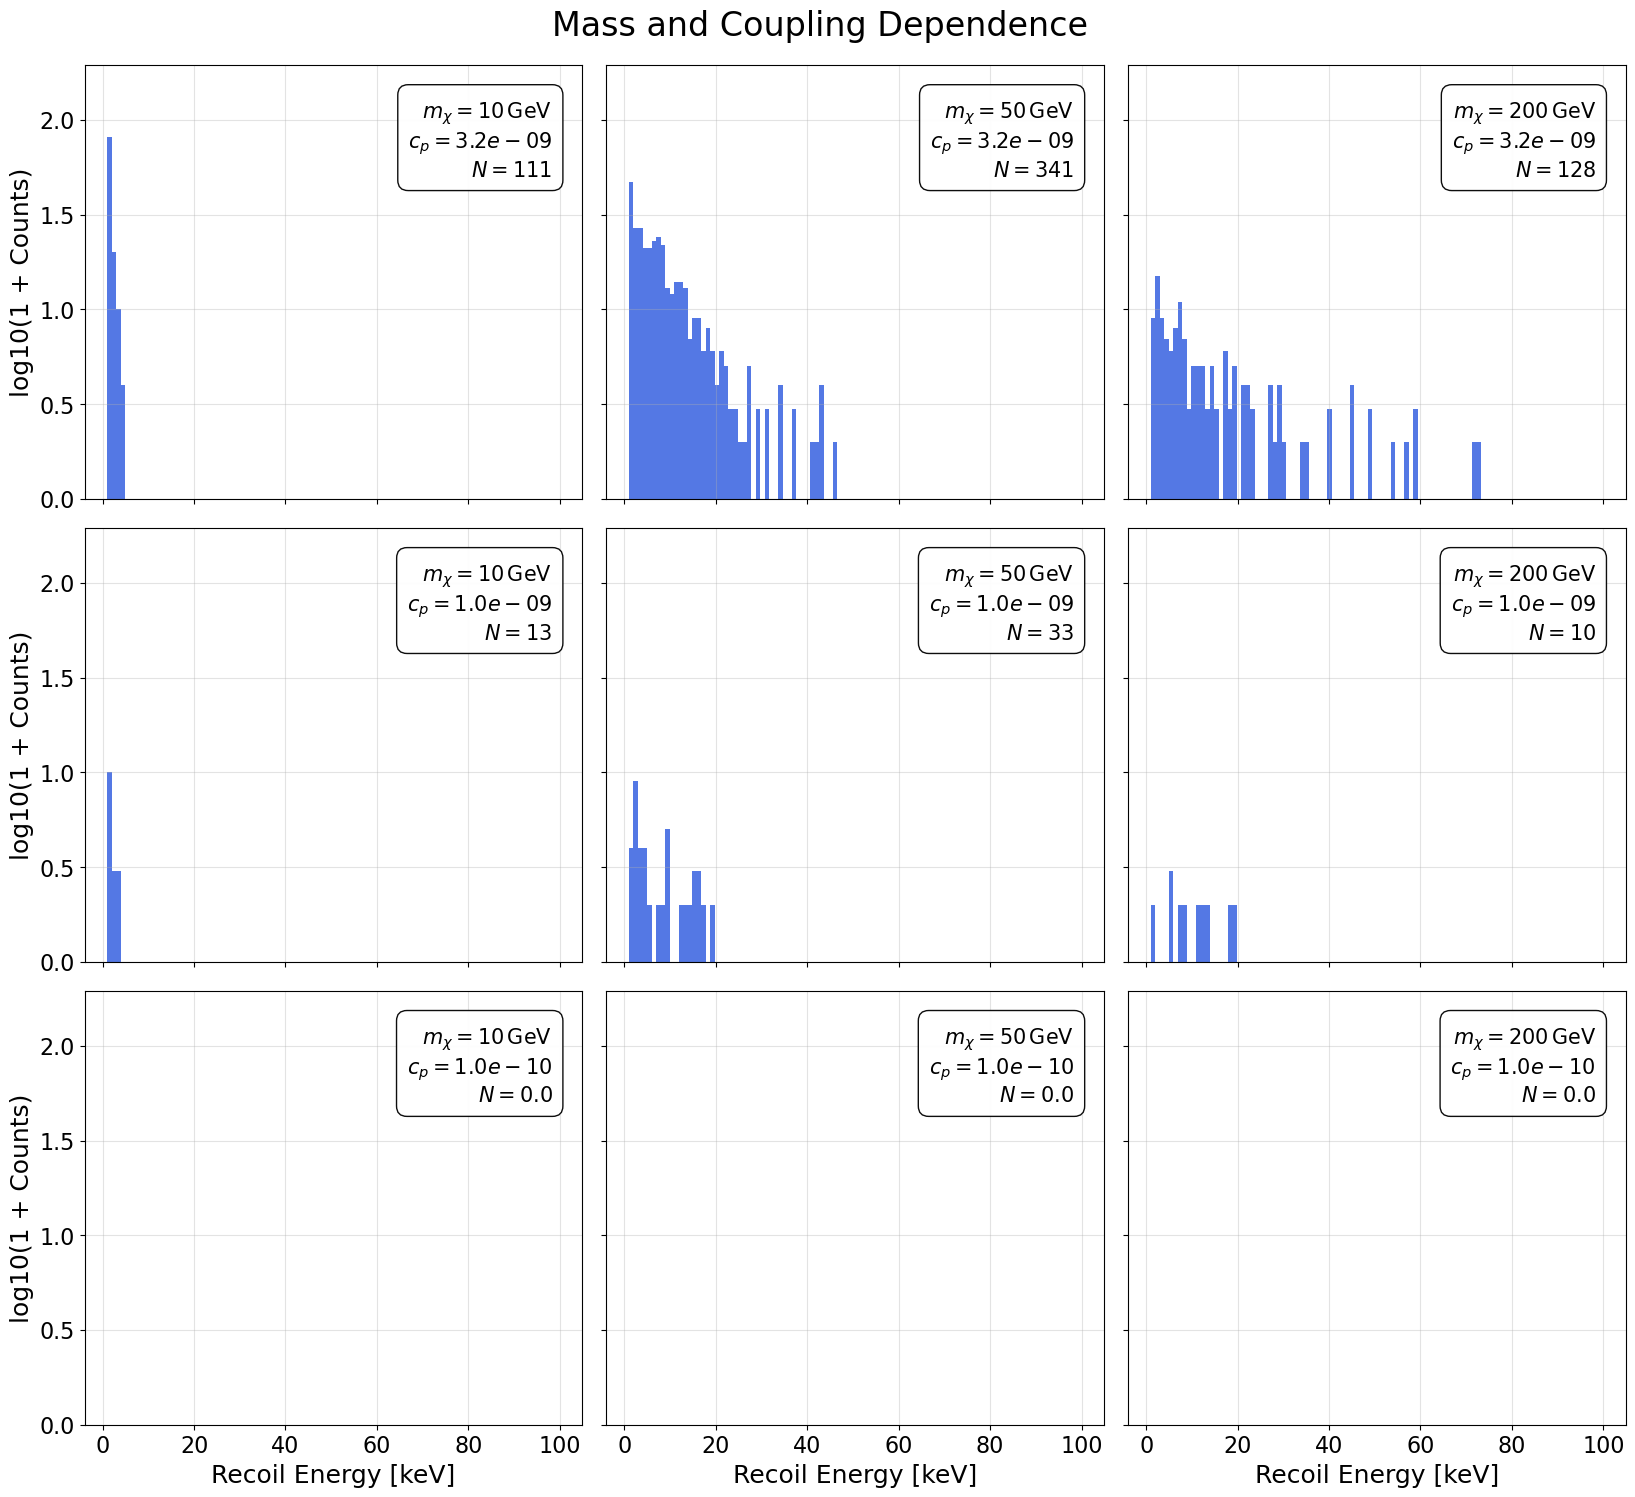

In [11]:
grid_masses = [10, 50, 200]
grid_couplings = [10**-8.5, 10**-9.0, 10**-10.0]
grid_cfg = MCConfig(log_bins=False)

fig, axes, all_spectra = plot_annotated_spectra_grid(
    grid_masses,
    grid_couplings,
    grid_cfg,
    log_transform=True,
    title="Mass and Coupling Dependence",
    color="royalblue"
)

# Save figure to PDF when needed.
# pdf_path = "figures/..."
# fig.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
plt.show()

## Comparison of the different data tags

In [12]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd
import torch

# Ensure we are at repository root.
desired_root_name = "xenon-sbi"
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

base = Path("data/datasets/wimpy/default")
pattern = re.compile(r"wimpy_n(\d+)_(low|mid|high)_default\.pt$")

files = []
for path in base.glob("wimpy_n*_default.pt"):
    match = pattern.match(path.name)
    if match:
        files.append((int(match.group(1)), match.group(2), path))

if not files:
    raise FileNotFoundError(f"No default low/mid/high files found in {base}")

by_n = {}
for sample_size, tag, path in files:
    by_n.setdefault(sample_size, {})[tag] = path

complete_sizes = [
    sample_size
    for sample_size, tags in by_n.items()
    if {"low", "mid", "high"}.issubset(tags)
]
if complete_sizes:
    chosen_n = max(complete_sizes)
    chosen = by_n[chosen_n]
else:
    chosen_n = None
    chosen = {}
    for tag in ["low", "mid", "high"]:
        candidates = [(sample_size, path) for sample_size, current_tag, path in files if current_tag == tag]
        if candidates:
            _, chosen[tag] = max(candidates, key=lambda item: item[0])

rows = []
for tag in ["low", "mid", "high"]:
    if tag not in chosen:
        rows.append({
            "case": tag,
            "n_spectra": np.nan,
            "max_events": np.nan,
            "avg_events_per_spectrum": np.nan,
            "pct_zero_spectra": np.nan,
            "file": "MISSING",
        })
        continue

    dataset = torch.load(chosen[tag], weights_only=False)
    lengths = np.array([len(events) for events in dataset["events"]], dtype=float)
    rows.append({
        "case": tag,
        "n_spectra": int(lengths.size),
        "max_events": int(lengths.max()),
        "avg_events_per_spectrum": lengths.mean(),
        "pct_zero_spectra": 100.0 * (lengths == 0).mean(),
        "file": chosen[tag].name,
    })

summary = pd.DataFrame(rows)[[
    "case",
    "n_spectra",
    "max_events",
    "avg_events_per_spectrum",
    "pct_zero_spectra",
    "file",
]]

if summary["n_spectra"].notna().all():
    summary["n_spectra"] = summary["n_spectra"].astype(int)
if summary["max_events"].notna().all():
    summary["max_events"] = summary["max_events"].astype(int)

summary["avg_events_per_spectrum"] = summary["avg_events_per_spectrum"].map(
    lambda value: f"{value:.3f}" if pd.notna(value) else "-"
)
summary["pct_zero_spectra"] = summary["pct_zero_spectra"].map(
    lambda value: f"{value:.3f}%" if pd.notna(value) else "-"
)

display(summary)
print(
    f"Selected complete set n = {chosen_n}"
    if chosen_n is not None
    else "Selected best available per case"
)

,case,n_spectra,max_events,avg_events_per_spectrum,pct_zero_spectra,file
0,low,300000,396,14.884,54.215%,wimpy_n300000_low_default.pt
1,mid,300000,3751,147.882,35.517%,wimpy_n300000_mid_default.pt
2,high,300000,36545,1490.693,22.592%,wimpy_n300000_high_default.pt


Selected complete set n = 300000


**Note:** The `low` datatag is the most (or only) relevant for our analysis.